Here we have the imports needed

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import random
import yaml
from scipy.integrate import quad
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

We extract our dataset

\Points: 22   z ∈ [0.140, 0.980]
WOrkspace range: [0.0700, 1.0000]

      z    (1/N)dN/dz           σ    σ/y [%]
----------------------------------------------
 0.1400      0.116000    0.030676       26.4%
 0.1800      0.198000    0.037135       18.8%
 0.2200      0.247000    0.030561       12.4%
 0.2600      0.264000    0.028983       11.0%
 0.3000      0.308000    0.032171       10.4%
 0.3400      0.370000    0.032909        8.9%
 0.3800      0.426000    0.034713        8.1%
 0.4200      0.501000    0.038419        7.7%
 0.4600      0.577000    0.040927        7.1%
 0.5000      0.685000    0.041785        6.1%
 0.5400      0.833000    0.052811        6.3%
 0.5800      1.055000    0.074061        7.0%
 0.6200      1.311000    0.089039        6.8%
 0.6600      1.667000    0.087892        5.3%
 0.7000      2.080000    0.084119        4.0%
 0.7400      2.566000    0.116263        4.5%
 0.7800      2.934000    0.178037        6.1%
 0.8200      3.104000    0.234949        7.6%
 0.8600     

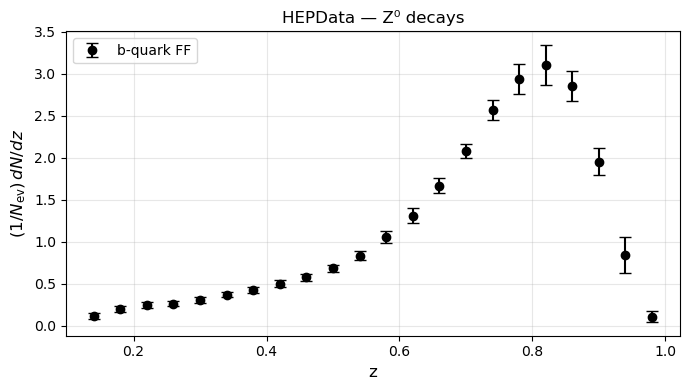

In [2]:
YAML_FILE="Table1.yaml"


def load_hepdata_yaml(filepath):
    """Load the HEPData dataset.
    REturns z_data, y_data, sigma_data.
    """
    with open(filepath, 'r') as f:
        raw = yaml.safe_load(f)

    #momentum fraction z
    indep = raw['independent_variables'][0]
    
    z_data = []
    for pt in indep['values']:
        if 'value' in pt:
            z_data.append(float(pt['value']))
        elif 'low' in pt and 'high' in pt:
            z_data.append(0.5 * (float(pt['low']) + float(pt['high'])))
        else:
            raise ValueError(f"unexpected format: {pt}")
    z_data = np.array(z_data)

    # (1/N) dN/dx
    dep = raw['dependent_variables'][0]

    y_data, sigma_data = [], []
    for pt in dep['values']:
        y_data.append(float(pt['value']))
        err_sq = 0.0
        for err in pt.get('errors', []):
            if 'symerror' in err:
                err_sq += float(err['symerror'])**2
            elif 'asymerror' in err:
                up = abs(float(err['asymerror'].get('plus',  0)))
                dn = abs(float(err['asymerror'].get('minus', 0)))
                err_sq += ((up + dn) / 2.0)**2
        sigma_data.append(max(np.sqrt(err_sq), 1e-6))

    return z_data, np.array(y_data), np.array(sigma_data)

z_data, y_data, sigma_data = load_hepdata_yaml(YAML_FILE)


Z_MIN = max(z_data.min() * 0.5, 1e-4)  
Z_MAX = min(z_data.max() * 1.05, 1)

print(f"\Points: {len(z_data)}   z ∈ [{z_data.min():.3f}, {z_data.max():.3f}]")
print(f"WOrkspace range: [{Z_MIN:.4f}, {Z_MAX:.4f}]")
print(f"\n{'z':>7}  {'(1/N)dN/dz':>12}  {'σ':>10}  {'σ/y [%]':>9}")
print("-" * 46)
for z, y, s in zip(z_data, y_data, sigma_data):
    print(f"{z:7.4f}  {y:12.6f}  {s:10.6f}  {100*s/max(abs(y),1e-9):9.1f}%")

plt.figure(figsize=(7, 4))
plt.errorbar(z_data, y_data, yerr=sigma_data,
             fmt='ko', capsize=4, label='b-quark FF')
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
plt.title('HEPData — Z⁰ decays')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



We define our variables that define our phase space and the number of qubits needed

In [3]:

PARAM_NAMES      = ['N', 'epsilon']

# ranges
#   N       ∈ [0.0001, 5.0]    normalization
#   epsilon ∈ [0.00001, 0.30]  Peterson's parameter for heavy quarks
#            (tipically: ε_b ≈ 0.006 – 0.030)
PARAM_MIN        = np.array([0.0001,  0.00001])
PARAM_MAX        = np.array([5.0,   0.30 ])
N_PARAMS         = 2
QUBITS_PER_PARAM = 5
NUM_QUBITS       = N_PARAMS * QUBITS_PER_PARAM   

print(f"REsolution: 2^{QUBITS_PER_PARAM} = {2**QUBITS_PER_PARAM} values per parameter")
for name, lo, hi in zip(PARAM_NAMES, PARAM_MIN, PARAM_MAX):
    step = (hi - lo) / (2**QUBITS_PER_PARAM-1)
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]   step = {step:.6f}")



def peterson_raw(z, N, epsilon):
    """D(z; N, ε) = N / [z * (1 - 1/z - ε/(1-z))²]
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    denom_inner = 1.0 - 1.0/z - epsilon/(1.0 - z)
    denom = z * denom_inner**2
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)   # FF is positive


_norm_cache = {}  

def compute_norm(N, epsilon, z_lo=Z_MIN, z_hi=Z_MAX):
    """Integral numérica de D(z; N, ε) en [z_lo, z_hi]."""
    key = (round(N, 6), round(epsilon, 8))
    if key in _norm_cache:
        return _norm_cache[key]
    val, _ = quad(lambda z: peterson_raw(z, N, epsilon),
                  z_lo, z_hi, limit=100,
                  points=[1.0/(1.0 + epsilon**0.5)])  # pico analítico
    _norm_cache[key] = val
    return val


def ff_model(z, theta):
    N, epsilon = theta
    if N <= 0 or epsilon <= 0:
        return np.zeros_like(np.asarray(z, dtype=float))
    return peterson_raw(z, N, epsilon)


def chi2_ff(theta):
    """χ²(θ) = Σ [(D̃_modell - y)² / σ²]"""
    f = ff_model(z_data, theta)
    if not np.all(np.isfinite(f)):
        return 1e12
    chi2 = float(np.sum(((f - y_data) / sigma_data)**2))
    return chi2 if np.isfinite(chi2) else 1e12



REsolution: 2^5 = 32 values per parameter
  N       : [0.0001, 5.0000]   step = 0.161287
  epsilon : [0.0000, 0.3000]   step = 0.009677



Best classical:
  N = 0.3847   ε = 0.03078
  χ² = 71.6917   χ²/n = 3.2587


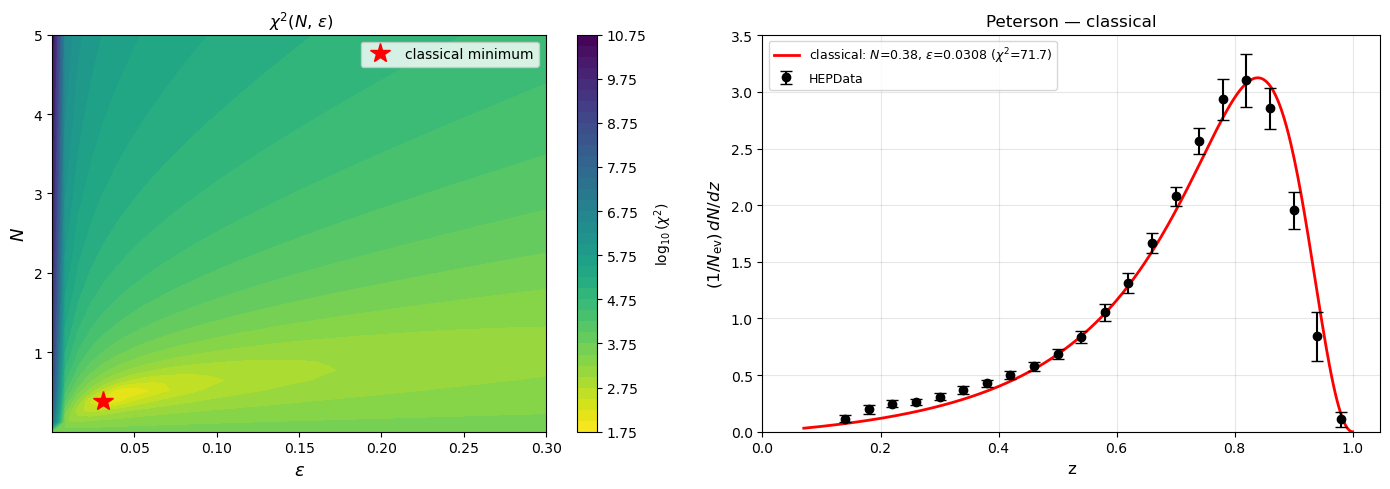

In [4]:
# ================================================================
#  Classical scan
# ================================================================
n_scan   = 40
N_scan   = np.linspace(PARAM_MIN[0], PARAM_MAX[0], n_scan)
eps_scan = np.linspace(PARAM_MIN[1], PARAM_MAX[1], n_scan)
chi2_map = np.zeros((n_scan, n_scan))

for i, N_val in enumerate(N_scan):
    for j, eps_val in enumerate(eps_scan):
        chi2_map[i, j] = chi2_ff([N_val, eps_val])


idx       = np.unravel_index(np.argmin(chi2_map), chi2_map.shape)
N_cl      = N_scan[idx[0]]
eps_cl    = eps_scan[idx[1]]
chi2_cl   = chi2_map[idx]
theta_cl  = [N_cl, eps_cl]

print(f"\nBest classical:")
print(f"  N = {N_cl:.4f}   ε = {eps_cl:.5f}")
print(f"  χ² = {chi2_cl:.4f}   χ²/n = {chi2_cl/len(z_data):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# χ² map
im = axes[0].contourf(eps_scan, N_scan,
                      np.log10(np.clip(chi2_map, 1e-3, None)),
                      levels=40, cmap='viridis_r')
plt.colorbar(im, ax=axes[0], label=r'$\log_{10}(\chi^2)$')
axes[0].plot(eps_cl, N_cl, 'r*', markersize=15, label='classical minimum')
axes[0].set_xlabel(r'$\varepsilon$', fontsize=13)
axes[0].set_ylabel(r'$N$', fontsize=13)
axes[0].set_title(r' $\chi^2(N,\,\varepsilon)$')
axes[0].legend()

# Best classical fit
z_fine  = np.linspace(Z_MIN, Z_MAX, 500)
f_cl    = ff_model(z_fine, theta_cl)
axes[1].errorbar(z_data, y_data, yerr=sigma_data,
                 fmt='ko', capsize=4, label='HEPData', zorder=5)
axes[1].plot(z_fine, f_cl, 'r-', lw=2,
             label=rf'classical: $N$={N_cl:.2f}, $\varepsilon$={eps_cl:.4f}'
                   rf' ($\chi^2$={chi2_cl:.1f})')
axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
axes[1].set_title('Peterson — classical')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Instead of anoisy backed we use a normal one

In [5]:
def get_backend():
    return AerSimulator()

Quantum operators

In [6]:

def initialize_chromosome(num_qubits):

    qc = QuantumCircuit(num_qubits)


    qc.h(range(num_qubits))


    for k in range(N_PARAMS):
        base = k * QUBITS_PER_PARAM
        for i in range(base, base + QUBITS_PER_PARAM - 1):
            qc.cx(i, i + 1)

    qc.barrier()
    return qc


def measure_chromosome(qc, backend):

    qc_m = qc.copy()
    qc_m.measure_all()
    qc_m   = transpile(qc_m, backend)
    counts = backend.run(qc_m, shots=1).result().get_counts()
    return list(counts.keys())[0][::-1]   

def decode_parameters(binary_string):

    max_int = (2 ** QUBITS_PER_PARAM) - 1   
    params  = []
    for k in range(N_PARAMS):
        chunk   = binary_string[k * QUBITS_PER_PARAM : (k + 1) * QUBITS_PER_PARAM]
        int_val = int(chunk, 2)             
        val     = PARAM_MIN[k] + (PARAM_MAX[k] - PARAM_MIN[k]) * (int_val / max_int)
        params.append(val)
    return np.array(params)


def apply_rotation(qc, best_binary, rotation_angle):
    """
      best_bit = 1 → RY(+θ)  (grows P(|1⟩))
      best_bit = 0 → RY(−θ)  (grows P(|0⟩))
    """
    for i in range(qc.num_qubits):
        if i >= len(best_binary):
            continue
        direction = +1 if int(best_binary[i]) == 1 else -1
        qc.ry(direction * rotation_angle, i)

    # Re-entrelazar tras la rotación
    for k in range(N_PARAMS):
        base = k * QUBITS_PER_PARAM
        for i in range(base, base + QUBITS_PER_PARAM - 1):
            qc.cx(i, i + 1)
    return qc


def apply_mutation(qc, mutation_rate):
    
    qc.barrier()
    for i in range(qc.num_qubits):
        if random.random() < mutation_rate:
            qc.x(i)
    return qc

In [7]:
def run_qga(generations=80, population_size=20,
            rotation_angle=0.10, mutation_rate=0.04):
   
    backend    = get_backend()
    population = [initialize_chromosome(NUM_QUBITS)
                  for _ in range(population_size)]

    best_chi2   = float('inf')
    best_binary = None
    best_theta  = np.array([1.0, 0.006])  
    history     = []

    print(f"QGA — Peterson | {NUM_QUBITS} qubits | "
          f"pop={population_size} | gens={generations}")
    print(f"Classically: χ² = {chi2_cl:.4f}")
    print("=" * 60)

    for gen in range(generations):
        gen_best_chi2   = float('inf')
        gen_best_binary = None

        for qc in population:
            binary = measure_chromosome(qc, backend)
            theta  = decode_parameters(binary)
            chi2   = chi2_ff(theta)

            if chi2 < gen_best_chi2:
                gen_best_chi2   = chi2
                gen_best_binary = binary

            if chi2 < best_chi2:
                best_chi2   = chi2
                best_binary = binary
                best_theta  = theta.copy()

        history.append(best_chi2)

        if gen_best_binary:
            for i in range(len(population)):
                population[i] = apply_rotation(
                    population[i], gen_best_binary, rotation_angle)
                population[i] = apply_mutation(
                    population[i], mutation_rate)

        if (gen + 1) % 10 == 0 or gen == 0:
            print(f"Gen {gen+1:03d}: χ² = {best_chi2:9.4f}  "
                  f"N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

    print("=" * 60)
    print(f"χ²_QGA  = {best_chi2:.6f}   χ²/n = {best_chi2/len(z_data):.4f}")
    print(f"χ²_clss = {chi2_cl:.6f}   χ²/n = {chi2_cl/len(z_data):.4f}")
    print(f"N       = {best_theta[0]:.6f}")
    print(f"ε       = {best_theta[1]:.6f}")
    z_peak = 1.0 / (1.0 + best_theta[1]**0.5)
    print(f"z* (pico) = {z_peak:.4f}")

    return best_chi2, best_theta, population, history, best_binary


best_chi2, best_theta, pop, history, best_binary = run_qga(
    generations     = 50,
    population_size = 20,
    rotation_angle  = 0.04,
    mutation_rate   = 0.09
)

QGA — Peterson | 10 qubits | pop=20 | gens=50
Classically: χ² = 71.6917
Gen 001: χ² = 1504.9927  N = 0.9678   ε = 0.30000
Gen 010: χ² =  360.1382  N = 0.3227   ε = 0.03872
Gen 020: χ² =  360.1382  N = 0.3227   ε = 0.03872
Gen 030: χ² =  332.4768  N = 0.6452   ε = 0.06775
Gen 040: χ² =  332.4768  N = 0.6452   ε = 0.06775
Gen 050: χ² =   84.5167  N = 0.4840   ε = 0.04840
χ²_QGA  = 84.516747   χ²/n = 3.8417
χ²_clss = 71.691734   χ²/n = 3.2587
N       = 0.483961
ε       = 0.048395
z* (pico) = 0.8197


Final corquit
  gates    : 962
  deep: 273
  binary chain: 0001100101
  N = 0.4840   ε = 0.04840


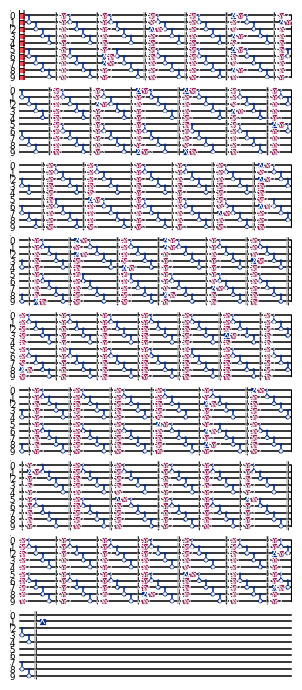

In [8]:

best_qc = pop[0]

print("Final corquit")
print(f"  gates    : {best_qc.size()}")
print(f"  deep: {best_qc.depth()}")
print(f"  binary chain: {best_binary}")
print(f"  N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

fig2 = best_qc.draw(output='mpl', style='iqp', fold=40, scale=0.55)
fig2.set_size_inches(20, 7)
plt.tight_layout()
plt.show()


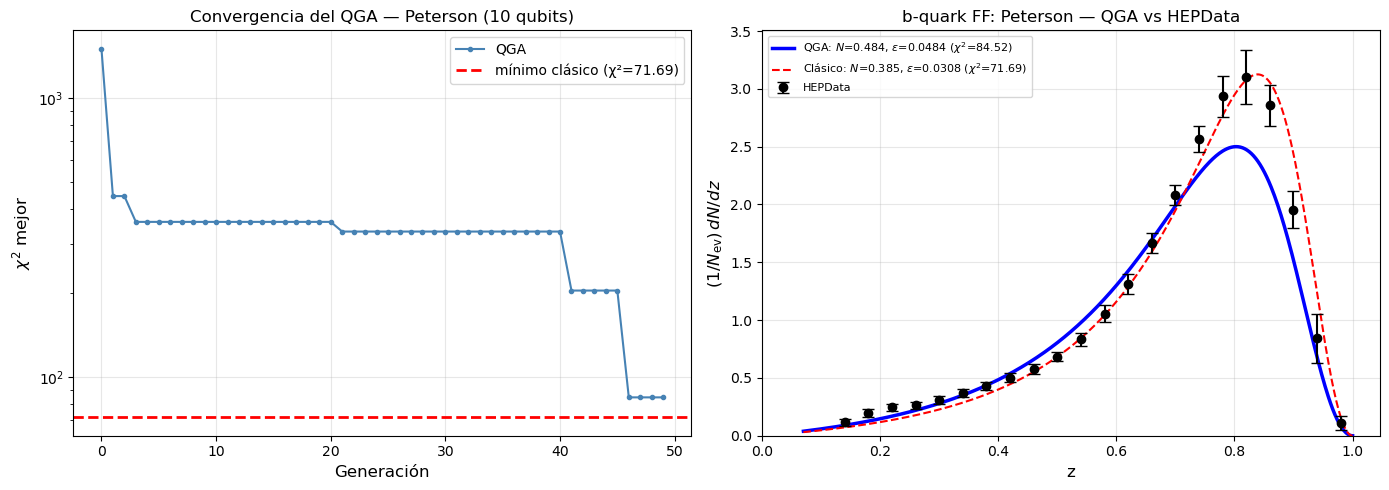


      z        data   Peterson QGA    (f-d)/σ
----------------------------------------------
 0.1400     0.11600        0.08995     -0.849
 0.1800     0.19800        0.12626     -1.932
 0.2200     0.24700        0.16903     -2.551
 0.2600     0.26400        0.21958     -1.533
 0.3000     0.30800        0.27949     -0.886
 0.3400     0.37000        0.35075     -0.585
 0.3800     0.42600        0.43573      0.280
 0.4200     0.50100        0.53734      0.946
 0.4600     0.57700        0.65899      2.003
 0.5000     0.68500        0.80462      2.863
 0.5400     0.83300        0.97845      2.754
 0.5800     1.05500        1.18435      1.747
 0.6200     1.31100        1.42446      1.274
 0.6600     1.66700        1.69624      0.333
 0.7000     2.08000        1.98688     -1.107
 0.7400     2.56600        2.26382     -2.599
 0.7800     2.93400        2.46181     -2.652
 0.8200     3.10400        2.47450     -2.679
 0.8600     2.85600        2.17659     -3.787
 0.9000     1.95400        1.518

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Convergencia ---
axes[0].plot(history, 'o-', color='steelblue', markersize=3, lw=1.5, label='QGA')
axes[0].axhline(chi2_cl, color='red', ls='--', lw=2,
                label=f'mínimo clásico (χ²={chi2_cl:.2f})')
axes[0].set_xlabel('Generación', fontsize=12)
axes[0].set_ylabel(r'$\chi^2$ mejor', fontsize=12)
axes[0].set_title('Convergencia del QGA — Peterson (10 qubits)')
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Ajuste vs datos ---
z_fine    = np.linspace(Z_MIN, Z_MAX, 500)
f_qga     = ff_model(z_fine, best_theta)
f_cl_fine = ff_model(z_fine, theta_cl)

axes[1].errorbar(z_data, y_data, yerr=sigma_data,
                 fmt='ko', capsize=4, label='HEPData', zorder=5)
axes[1].plot(z_fine, f_qga, 'b-', lw=2.5,
             label=(rf'QGA: $N$={best_theta[0]:.3f}, '
                    rf'$\varepsilon$={best_theta[1]:.4f} '
                    rf'($\chi^2$={best_chi2:.2f})'))
axes[1].plot(z_fine, f_cl_fine, 'r--', lw=1.5,
             label=(rf'Clásico: $N$={theta_cl[0]:.3f}, '
                    rf'$\varepsilon$={theta_cl[1]:.4f} '
                    rf'($\chi^2$={chi2_cl:.2f})'))



axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
axes[1].set_title('b-quark FF: Peterson — QGA vs HEPData')
axes[1].legend(fontsize=8)
axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# table
f_pts = ff_model(z_data, best_theta)
print(f"\n{'z':>7}  {'data':>10}  {'Peterson QGA':>13}  {'(f-d)/σ':>9}")
print("-" * 46)
for z, yd, fm, s in zip(z_data, y_data, f_pts, sigma_data):
    print(f"{z:7.4f}  {yd:10.5f}  {fm:13.5f}  {(fm-yd)/s:9.3f}")

print(f"\n{'Resultado final':=^46}")
print(f"  N         = {best_theta[0]:.6f}")
print(f"  ε         = {best_theta[1]:.6f}")
print(f"  χ²/n QGA  = {best_chi2/len(z_data):.4f}")
print(f"  χ²/n clás = {chi2_cl/len(z_data):.4f}")